# 그린바이오 기반 식품소재 첨단농장 데이터 — EDA

[AI Hub 그린바이오 기반 식품소재 첨단농장 데이터] 샘플(`green_bio_farm.zip`)의 탐색적 데이터 분석(EDA)입니다.

| 항목 | 내용 |
|------|------|
| 데이터 | 스마트팜에서 재배한 9종 식품소재 작물의 생육 이미지 |
| 구성 | JPG 25,602장 + JSON 25,602개 (이미지-라벨 1:1 페어) |
| 작물 | 밀순 / 새싹인삼(개량종·연풍) / 양상추 / 녹차 / 두메부추 / 팥순 / 구절초(넓은잎·좁은잎) |
| 구분축 | 생육단계(생장·수확) × 촬영방향(사이드뷰·탑뷰) |
| 라벨 | `줄기`·`잎` 부위별 **2점 폴리라인**(길이 측정용 키포인트) |
| 부가정보 | 재배환경 센서(온도·습도·CO2·조도·EC·pH 등) + 생육 실측치 + 캡션 |

<br>

> 이 노트북은 `14_Air_Fitting_EDA.ipynb`의 구성을 참고해 작성되었습니다.
> 에어피팅 데이터가 **B-box 기반 객체 검출**용인 반면, 본 데이터는
> **부위별 키포인트/폴리라인 + 시계열 생육·환경 메타데이터**가 핵심입니다.


## 0. 환경 설정

In [1]:
import json
import re
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd()
if not (ROOT / "green_bio_farm.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "green_bio_farm.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "green_bio_farm.zip"
DATA_ROOT = ROOT / "green_bio_farm"
EDA_OUT = DATA_ROOT / "eda"

RAW_DIR_NAME = "01.\uc6d0\ucc9c\ub370\uc774\ud130"      # 01.원천데이터
LABEL_DIR_NAME = "02.\ub77c\ubca8\ub9c1\ub370\uc774\ud130"  # 02.라벨링데이터


def _iter_files(root: Path, suffix: str):
    return [p for p in root.rglob(f"*{suffix}") if "eda" not in p.parts]


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    return len(_iter_files(root, ".jpg")) > 0 and len(_iter_files(root, ".json")) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = {p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"}
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"\uc555\ucd95 \ud30c\uc77c\uc774 \uc5c6\uc2b5\ub2c8\ub2e4: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            # 최상위 green_bio_farm/ 래퍼 폴더는 벗겨서 DATA_ROOT 바로 아래로 전개
            parts = name.split("/")
            if parts and parts[0] == extract_to.name:
                name = "/".join(parts[1:])
            if not name:
                continue
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_raw_and_label_roots(root: Path):
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    cands = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (max(cands, key=lambda p: len(list(p.rglob("*.jpg")))),
            max(cands, key=lambda p: len(list(p.rglob("*.json")))))


print(f"ROOT      : {ROOT.resolve()}")
print(f"ZIP \uc874\uc7ac  : {ZIP_PATH.exists()}")
print(f"\ub370\uc774\ud130 \uc900\ube44: {data_is_ready(DATA_ROOT)}")
print(f"\ud55c\uae00 \uacbd\ub85c : {has_correct_korean_paths(DATA_ROOT)}")


ROOT      : C:\MyCursorLab\08_Object_Detection
ZIP 존재  : True
데이터 준비: True
한글 경로 : True


## 1. 압축 해제 및 폴더 구조

`green_bio_farm.zip` 에는 이미지 약 25,600장(≈1.2GB)이 들어 있어 첫 실행 시 압축 해제에
수 분이 걸릴 수 있습니다. 두 번째 실행부터는 `data_is_ready()` 검사로 건너뜁니다.

In [2]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"zip \ud30c\uc77c\uc774 \uc5c6\uc2b5\ub2c8\ub2e4: {ZIP_PATH}")

need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)
print("\uc555\ucd95 \ud574\uc81c \uc644\ub8cc" if need_extract else "\ub370\uc774\ud130 \ud3f4\ub354 \uc0ac\uc6a9 (\uc774\ubbf8 \uc555\ucd95 \ud574\uc81c\ub428)")

EDA_OUT.mkdir(parents=True, exist_ok=True)
raw_root, label_root = find_raw_and_label_roots(DATA_ROOT)

crop_dirs = sorted(p.name for p in label_root.iterdir() if p.is_dir())
print(f"\uc6d0\ucc9c \ub370\uc774\ud130 : {raw_root.name}")
print(f"\ub77c\ubca8 \ub370\uc774\ud130 : {label_root.name}")
print(f"\uc791\ubb3c \ud3f4\ub354 {len(crop_dirs)}\uc885 : {crop_dirs}")

# 폴더 계층: <작물>/<생육단계>/<촬영방향>/<파일>
rows = []
for crop in crop_dirs:
    for phase_dir in sorted((label_root / crop).iterdir()):
        if not phase_dir.is_dir():
            continue
        for view_dir in sorted(phase_dir.iterdir()):
            if not view_dir.is_dir():
                continue
            n_json = len(list(view_dir.glob("*.json")))
            n_jpg = len(list((raw_root / crop / phase_dir.name / view_dir.name).glob("*.jpg")))
            rows.append({
                "\uc791\ubb3c": crop.split(".")[-1],
                "\uc0dd\uc721\ub2e8\uacc4": phase_dir.name.split(".")[-1],
                "\ucd2c\uc601\ubc29\ud5a5": view_dir.name.split(".")[-1],
                "JPG": n_jpg,
                "JSON": n_json,
            })

df_tree = pd.DataFrame(rows)
print(f"\n\ucd1d \uc774\ubbf8\uc9c0: {df_tree['JPG'].sum():,}\uc7a5 / \ucd1d \ub77c\ubca8: {df_tree['JSON'].sum():,}\uac1c")
display(df_tree)


데이터 폴더 사용 (이미 압축 해제됨)
원천 데이터 : 01.원천데이터
라벨 데이터 : 02.라벨링데이터
작물 폴더 9종 : ['01.밀순', '02.새싹인삼_개량종', '03.새싹인삼_연풍', '04.양상추', '05.녹차', '06.두메부추', '07.팥순', '08.구절초_넓은잎', '09.구절초_좁은잎']

총 이미지: 25,602장 / 총 라벨: 25,602개


,작물,생육단계,촬영방향,JPG,JSON
0,밀순,생장,사이드뷰,1692,1692
1,밀순,생장,탑뷰,707,707
2,밀순,수확,사이드뷰,799,799
3,밀순,수확,탑뷰,1071,1071
4,새싹인삼_개량종,생장,사이드뷰,1182,1182
5,새싹인삼_개량종,생장,탑뷰,414,414
6,새싹인삼_개량종,수확,사이드뷰,352,352
7,새싹인삼_개량종,수확,탑뷰,266,266
8,새싹인삼_연풍,생장,사이드뷰,722,722
9,새싹인삼_연풍,생장,탑뷰,617,617


## 2. 메타데이터 수집

모든 JSON을 순회하며 `images / labels / environment / growth / caption` 5개 블록을
하나의 평면 레코드로 펼쳐 `df` 를 만듭니다. (약 25,600개 → 수십 초 소요)

- **`quality_status`** 필드는 값이 `G`(생장) / `P`(수확)로, 폴더의 생육단계와 동일 축입니다.
- 환경/생육 수치에는 결측 표기(`""`, `"-"`)가 섞여 있어 `_to_float()` 로 안전 변환합니다.
- 라벨(`labels`)은 부위별 2점 폴리라인이며, 두 점 사이 **픽셀 거리**를 세그먼트 길이로 계산합니다.

In [3]:
def _to_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan


def _flatten_divide(raw):
    out = []
    for d in raw or []:
        out.append(d[0] if isinstance(d, list) and d else d)
    return [x for x in out if x]


def _segment_lengths(points):
    lens = []
    for seg in points or []:
        if isinstance(seg, list) and len(seg) >= 2:
            (x1, y1), (x2, y2) = seg[0][:2], seg[1][:2]
            lens.append(float(np.hypot(x2 - x1, y2 - y1)))
    return lens


def parse_record(json_path: Path) -> dict:
    data = json.loads(json_path.read_text(encoding="utf-8-sig"))
    img = data.get("images", {}) or {}
    lab = data.get("labels", {}) or {}
    env = data.get("environment", {}) or {}
    grw = data.get("growth", {}) or {}
    cap = data.get("caption", {}) or {}

    rel = json_path.relative_to(label_root)
    crop_dir, phase_dir, view_dir = rel.parts[0], rel.parts[1], rel.parts[2]

    divides = _flatten_divide(lab.get("label_divide"))
    seg_lens = _segment_lengths(lab.get("label_points"))

    # \ub77c\ubca8 \uc88c\ud45c\ub294 \uc6d0\ubcf8 \ud574\uc0c1\ub3c4(1920 \ub610\ub294 3840) \uae30\uc900 \u2192 \ud574\uc0c1\ub3c4 \uc601\ud5a5\uc744 \uc5c6\uc560\uae30 \uc704\ud574
    # \uc774\ubbf8\uc9c0 \ub300\uac01\uc120 \uae38\uc774\ub85c \ub098\ub208 '\uc0c1\ub300 \uae38\uc774'\ub3c4 \ud568\uaed8 \uacc4\uc0b0
    diag = float(np.hypot(img.get("imagewidth") or 1, img.get("imageheight") or 1))
    seg_rel = [l / diag for l in seg_lens]

    stem_px = [l for d, l in zip(divides, seg_lens) if d == "\uc904\uae30"]
    leaf_px = [l for d, l in zip(divides, seg_lens) if d == "\uc78e"]
    stem_rel = [l for d, l in zip(divides, seg_rel) if d == "\uc904\uae30"]
    leaf_rel = [l for d, l in zip(divides, seg_rel) if d == "\uc78e"]

    return {
        "crop": img.get("class_name") or crop_dir.split(".")[-1],
        "phase": phase_dir.split(".")[-1],          # 생장 / 수확
        "view": view_dir.split(".")[-1],            # 사이드뷰 / 탑뷰
        "photo_direction": img.get("photo_direction"),   # SV / TV
        "quality_status": img.get("quality_status"),     # G / P
        "scenario": img.get("scenario"),
        "photographer": img.get("photographer_code"),
        "img_w": img.get("imagewidth"),
        "img_h": img.get("imageheight"),
        "photo_dt": pd.to_datetime(img.get("photo_date"), format="%y%m%d%H%M%S", errors="coerce"),
        # ----- labels -----
        "n_label": len(divides),
        "n_stem": divides.count("\uc904\uae30"),
        "n_leaf": divides.count("\uc78e"),
        "label_divide": ", ".join(divides),
        "seg_len_mean": float(np.mean(seg_lens)) if seg_lens else np.nan,
        "stem_px": float(np.mean(stem_px)) if stem_px else np.nan,
        "leaf_px": float(np.mean(leaf_px)) if leaf_px else np.nan,
        "stem_rel": float(np.mean(stem_rel)) if stem_rel else np.nan,
        "leaf_rel": float(np.mean(leaf_rel)) if leaf_rel else np.nan,
        # ----- environment -----
        "temp": _to_float(env.get("temp")),
        "humidity": _to_float(env.get("humidity")),
        "co2": _to_float(env.get("co2")),
        "lux": _to_float(env.get("lux")),
        "ec": _to_float(env.get("ec")),
        "ph": _to_float(env.get("ph")),
        "nutrient_temp": _to_float(env.get("nutrient_temperaturenumber")),
        # ----- growth -----
        "stem_length": _to_float(grw.get("stem_length")),
        "stalk_diameter": _to_float(grw.get("stalk_diameter")),
        "leaf_width": _to_float(grw.get("leaf_width")),
        "leaf_number": _to_float(grw.get("leaf_number")),
        "growth_cycle": _to_float(grw.get("growth_cycle")),
        "fruit_quantity": _to_float(grw.get("fruit_quantity")),
        # ----- caption -----
        "has_caption": bool(cap.get("image_caption")),
        "caption_len": len((cap.get("detail") or "")),
        # ----- paths -----
        "json_path": str(json_path),
        "img_path": str(raw_root / rel.with_suffix(".jpg")),
    }


json_files = sorted(label_root.rglob("*.json"))
print(f"\ud30c\uc2f1 \ub300\uc0c1 JSON: {len(json_files):,}\uac1c")

records = []
for i, jp in enumerate(json_files, 1):
    try:
        records.append(parse_record(jp))
    except Exception as e:  # noqa: BLE001
        print(f"  [skip] {jp.name}: {e}")
    if i % 4000 == 0:
        print(f"  ... {i:,} / {len(json_files):,}")

df = pd.DataFrame(records)
df["img_exists"] = df["img_path"].map(lambda p: Path(p).exists())
print(f"\n\ub808\ucf54\ub4dc: {len(df):,}\ud589 / \uceec\ub7fc: {df.shape[1]}\uac1c / \uc774\ubbf8\uc9c0 \uc874\uc7ac: {df['img_exists'].mean()*100:.1f}%")
display(df.head(3))


파싱 대상 JSON: 25,602개
  ... 4,000 / 25,602
  ... 8,000 / 25,602
  ... 12,000 / 25,602
  ... 16,000 / 25,602
  ... 20,000 / 25,602
  ... 24,000 / 25,602

레코드: 25,602행 / 컬럼: 37개 / 이미지 존재: 100.0%


,crop,phase,view,photo_direction,quality_status,scenario,photographer,img_w,img_h,photo_dt,n_label,n_stem,n_leaf,label_divide,seg_len_mean,stem_px,leaf_px,stem_rel,leaf_rel,temp,humidity,co2,lux,ec,ph,nutrient_temp,stem_length,stalk_diameter,leaf_width,leaf_number,growth_cycle,fruit_quantity,has_caption,caption_len,json_path,img_path,img_exists
0,밀순,생장,사이드뷰,SV,G,S2,W01,4000,2252,2024-07-12 13:15:31,2,1,1,"줄기, 잎",429.994456,176.379240,683.609673,0.038424,0.148923,33.22,63.72,497.0,2514.0,0.165,8.061,34.1,2.848,0.145,0.261,2.0,0.0,0.0,True,160,c:\MyCursorLab\08_Object_Detection\green_bio_f...,c:\MyCursorLab\08_Object_Detection\green_bio_f...,True
1,밀순,생장,사이드뷰,SV,G,S2,W01,4000,2252,2024-07-17 14:12:36,2,1,1,"줄기, 잎",461.019591,162.754740,759.284442,0.035456,0.165408,30.95,73.19,409.0,89.0,0.180,4.340,32.5,3.111,0.202,0.425,3.0,0.0,0.0,True,156,c:\MyCursorLab\08_Object_Detection\green_bio_f...,c:\MyCursorLab\08_Object_Detection\green_bio_f...,True
2,밀순,생장,사이드뷰,SV,G,S2,W12,1920,1080,2024-07-25 18:19:35,2,1,1,"줄기, 잎",280.628485,101.463315,459.793655,0.046059,0.208721,27.81,90.87,437.0,49.0,0.170,4.810,30.1,2.900,0.200,0.300,2.0,0.0,0.0,True,150,c:\MyCursorLab\08_Object_Detection\green_bio_f...,c:\MyCursorLab\08_Object_Detection\green_bio_f...,True


In [4]:
# 수치·결측 요약
num_cols = ["temp", "humidity", "co2", "lux", "ec", "ph", "nutrient_temp",
            "stem_length", "stalk_diameter", "leaf_width", "leaf_number",
            "growth_cycle", "seg_len_mean", "stem_px", "leaf_px"]
print("=== 결측률(%) ===")
display((df[num_cols].isna().mean() * 100).round(1).to_frame("missing_%"))
print("=== 기술통계 ===")
display(df[num_cols].describe().T.round(3))


=== 결측률(%) ===


,missing_%
temp,0.0
humidity,0.0
co2,0.0
lux,0.0
ec,0.0
ph,0.0
nutrient_temp,0.0
stem_length,0.0
stalk_diameter,0.0
leaf_width,0.0


=== 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
temp,25602.0,29.836,3.437,16.750,29.660,30.540,31.310,37.030
humidity,25602.0,67.358,11.159,24.490,62.250,68.680,74.070,92.990
co2,25602.0,470.500,54.708,30.900,434.000,463.000,497.000,913.000
lux,25602.0,556.864,817.278,0.797,30.000,143.000,1198.750,7361.000
ec,25602.0,1.098,20.788,0.000,0.000,0.000,0.200,516.000
ph,25602.0,7.235,1.222,0.480,6.530,7.880,7.980,17.000
nutrient_temp,25602.0,30.749,3.988,0.000,30.800,31.500,32.300,52.600
stem_length,25602.0,9.687,9.000,0.267,2.300,4.800,18.500,36.528
stalk_diameter,25602.0,0.475,0.396,0.000,0.200,0.270,0.600,4.970
leaf_width,25602.0,2.594,2.929,0.000,0.400,2.320,3.320,38.000


## 3. 분포 시각화 — 작물 / 생육단계 / 촬영방향 / 촬영자 / 시기

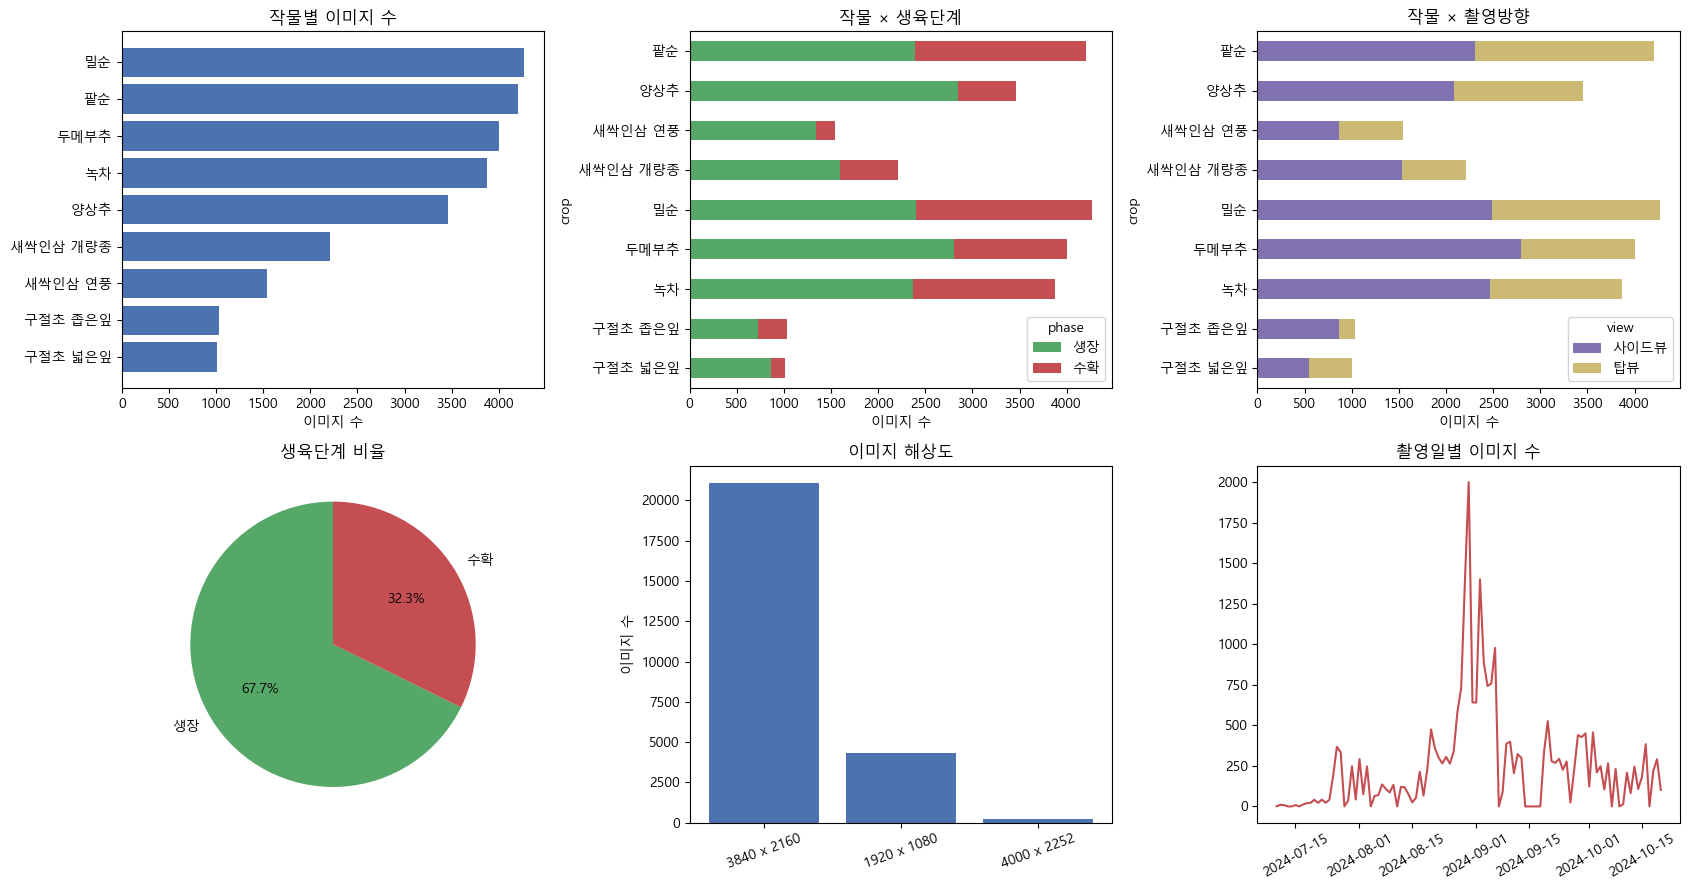

촬영자 코드 수: 31
{'W05': 7901, 'W25': 5507, 'W17': 3222, 'W18': 2329, 'W27': 1460, 'W28': 1435, 'W12': 733, 'W06': 630, 'W01': 365, 'W09': 342}


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

crop_cnt = df["crop"].value_counts()
axes[0, 0].barh(crop_cnt.index[::-1], crop_cnt.values[::-1], color="#4C72B0")
axes[0, 0].set_title("\uc791\ubb3c\ubcc4 \uc774\ubbf8\uc9c0 \uc218")
axes[0, 0].set_xlabel("\uc774\ubbf8\uc9c0 \uc218")

pv = df.groupby(["crop", "phase"]).size().unstack(fill_value=0)
pv.plot(kind="barh", stacked=True, ax=axes[0, 1], color=["#55A868", "#C44E52"])
axes[0, 1].set_title("\uc791\ubb3c \u00d7 \uc0dd\uc721\ub2e8\uacc4")
axes[0, 1].set_xlabel("\uc774\ubbf8\uc9c0 \uc218")

vv = df.groupby(["crop", "view"]).size().unstack(fill_value=0)
vv.plot(kind="barh", stacked=True, ax=axes[0, 2], color=["#8172B2", "#CCB974"])
axes[0, 2].set_title("\uc791\ubb3c \u00d7 \ucd2c\uc601\ubc29\ud5a5")
axes[0, 2].set_xlabel("\uc774\ubbf8\uc9c0 \uc218")

ph_cnt = df["phase"].value_counts()
axes[1, 0].pie(ph_cnt.values, labels=ph_cnt.index, autopct="%1.1f%%", startangle=90,
               colors=["#55A868", "#C44E52"])
axes[1, 0].set_title("\uc0dd\uc721\ub2e8\uacc4 \ube44\uc728")

res_cnt = (df["img_w"].astype("Int64").astype(str) + " x " + df["img_h"].astype("Int64").astype(str)).value_counts()
axes[1, 1].bar(res_cnt.index.astype(str), res_cnt.values, color="#4C72B0")
axes[1, 1].set_title("\uc774\ubbf8\uc9c0 \ud574\uc0c1\ub3c4")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].set_ylabel("\uc774\ubbf8\uc9c0 \uc218")

daily = df.dropna(subset=["photo_dt"]).set_index("photo_dt").resample("D").size()
axes[1, 2].plot(daily.index, daily.values, color="#C44E52")
axes[1, 2].set_title("\ucd2c\uc601\uc77c\ubcc4 \uc774\ubbf8\uc9c0 \uc218")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(EDA_OUT / "distribution_overview.png", dpi=120, bbox_inches="tight")
plt.show()

print("\ucd2c\uc601\uc790 \ucf54\ub4dc \uc218:", df["photographer"].nunique())
print(df["photographer"].value_counts().head(10).to_dict())


## 4. 재배환경 센서 분석 — 분포와 상관관계

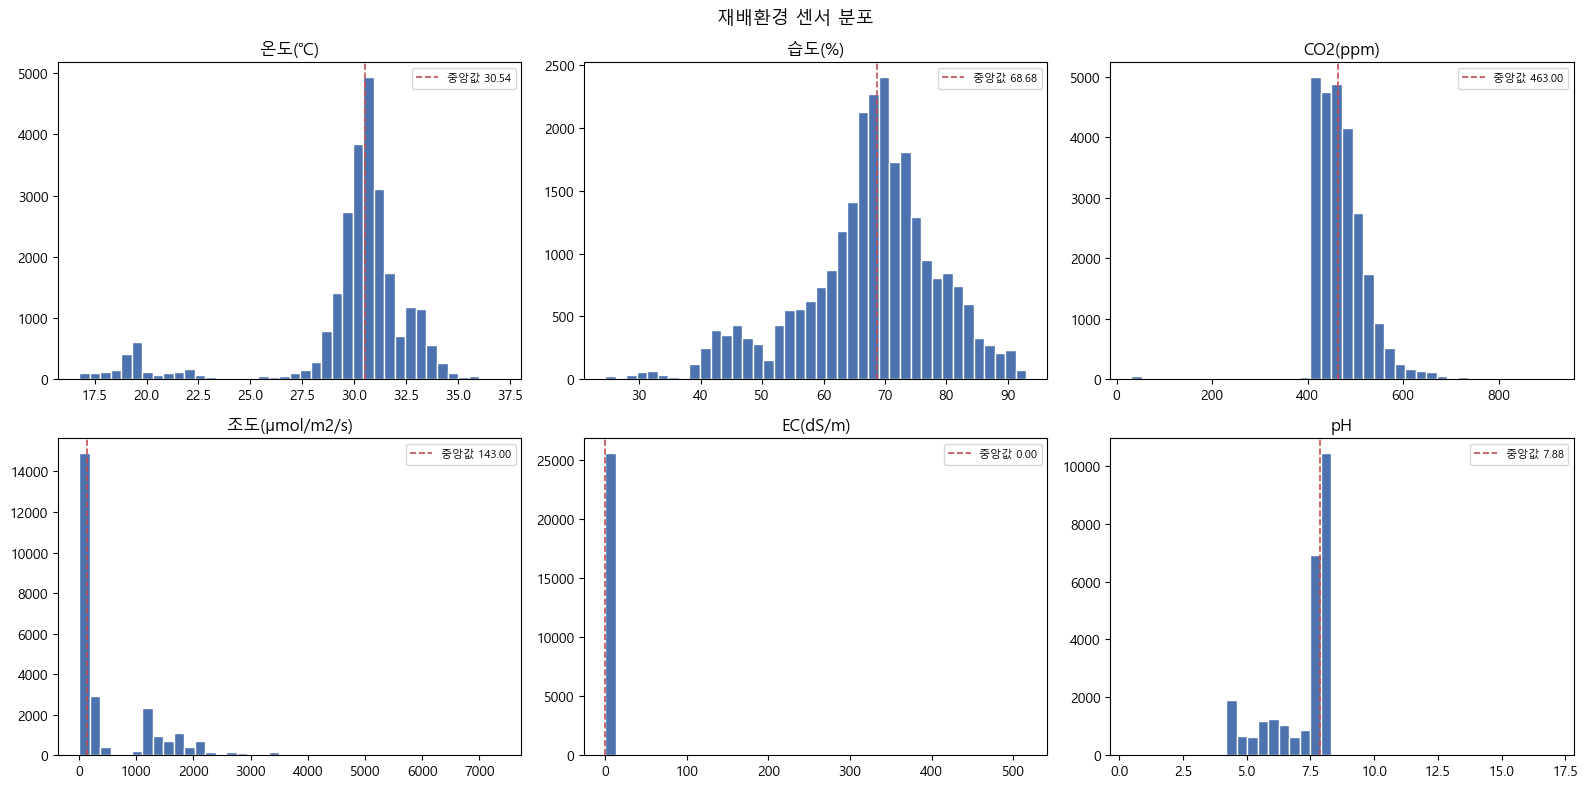

,temp,humidity,co2,lux,ec,ph
crop,,,,,,
구절초 넓은잎,30.68,69.46,460.0,50.0,0.42,6.38
구절초 좁은잎,30.82,66.86,473.0,1541.0,0.00,7.87
녹차,30.89,67.24,441.0,43.0,0.72,7.91
두메부추,30.17,66.80,485.0,217.0,0.10,5.59
밀순,30.56,70.36,462.0,77.0,0.00,7.92
새싹인삼 개량종,30.11,69.20,470.0,258.0,0.00,7.86
새싹인삼 연풍,30.13,69.16,461.0,238.0,0.20,6.10
양상추,21.07,71.78,512.0,19.0,0.00,7.93
팥순,31.09,67.14,447.0,53.0,0.00,7.93


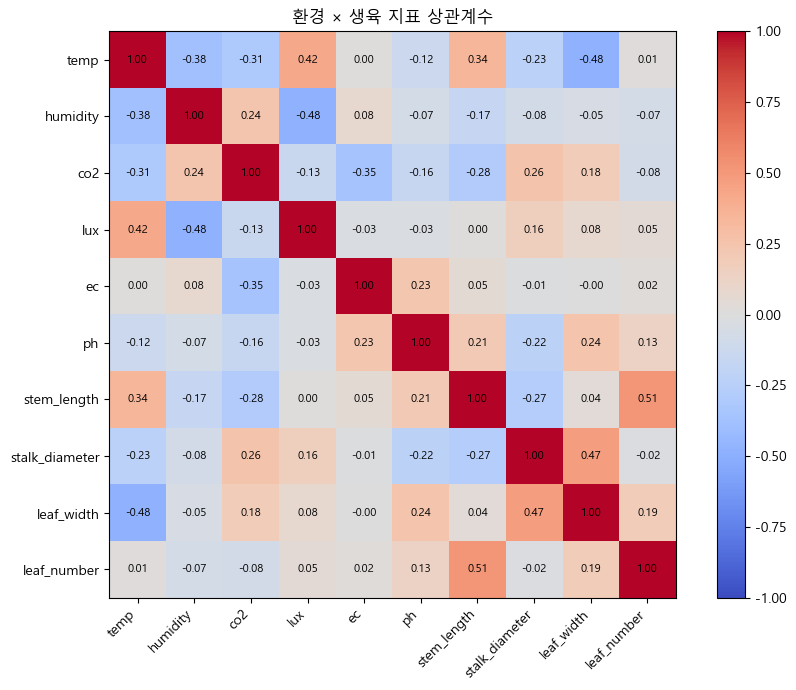

In [6]:
env_cols = ["temp", "humidity", "co2", "lux", "ec", "ph"]
titles = ["\uc628\ub3c4(\u2103)", "\uc2b5\ub3c4(%)", "CO2(ppm)", "\uc870\ub3c4(\u00b5mol/m2/s)", "EC(dS/m)", "pH"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, t in zip(axes.flat, env_cols, titles):
    ax.hist(df[col].dropna(), bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(t)
    ax.axvline(df[col].median(), color="#C44E52", ls="--", lw=1.2,
               label=f"\uc911\uc559\uac12 {df[col].median():.2f}")
    ax.legend(fontsize=8)
plt.suptitle("\uc7ac\ubc30\ud658\uacbd \uc13c\uc11c \ubd84\ud3ec", fontsize=13)
plt.tight_layout()
plt.savefig(EDA_OUT / "environment_dist.png", dpi=120, bbox_inches="tight")
plt.show()

# 작물별 환경 조건 (전체 레코드 중앙값)
env_by_crop = df.groupby("crop")[env_cols].median().round(2)
display(env_by_crop)

# 상관 히트맵
corr = df[env_cols + ["stem_length", "stalk_diameter", "leaf_width", "leaf_number"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("\ud658\uacbd \u00d7 \uc0dd\uc721 \uc9c0\ud45c \uc0c1\uad00\uacc4\uc218")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(EDA_OUT / "environment_corr.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. 생육 지표 분석 — 작물별 · 생육주차별 변화

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11568\545520578.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=crops, showfliers=False)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11568\545520578.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=crops, showfliers=False)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11568\545520578.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=crops, showfliers=False)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11568\545520578.py:8: MatplotlibDeprecationWarning

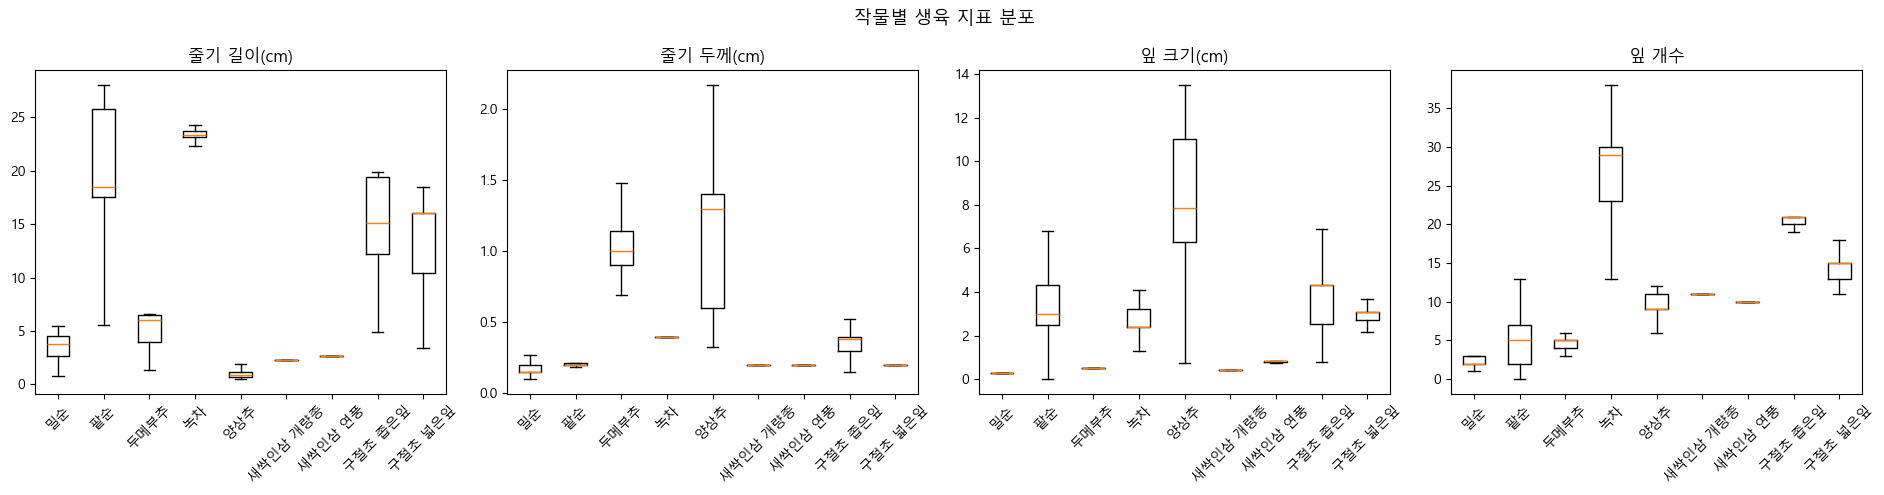

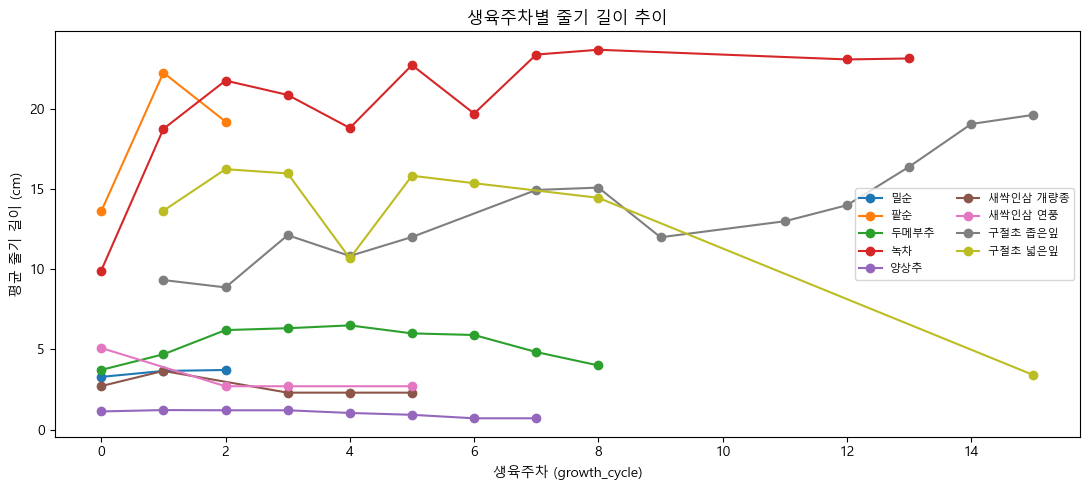

phase,생장,수확
crop,,
구절초 넓은잎,14.46,3.40
구절초 좁은잎,13.54,19.56
녹차,23.20,23.13
두메부추,5.89,4.42
밀순,3.60,3.42
새싹인삼 개량종,2.45,2.30
새싹인삼 연풍,2.80,2.70
양상추,0.98,0.70
팥순,22.01,14.96


In [7]:
grow_cols = ["stem_length", "stalk_diameter", "leaf_width", "leaf_number"]
grow_titles = ["\uc904\uae30 \uae38\uc774(cm)", "\uc904\uae30 \ub450\uaed8(cm)", "\uc78e \ud06c\uae30(cm)", "\uc78e \uac1c\uc218"]

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
crops = list(df["crop"].value_counts().index)
for ax, col, t in zip(axes, grow_cols, grow_titles):
    data = [df.loc[df["crop"] == c, col].dropna() for c in crops]
    ax.boxplot(data, labels=crops, showfliers=False)
    ax.set_title(t)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("\uc791\ubb3c\ubcc4 \uc0dd\uc721 \uc9c0\ud45c \ubd84\ud3ec", fontsize=13)
plt.tight_layout()
plt.savefig(EDA_OUT / "growth_by_crop.png", dpi=120, bbox_inches="tight")
plt.show()

# 생육주차(growth_cycle)별 평균 줄기 길이 추이
fig, ax = plt.subplots(figsize=(11, 5))
for c in crops:
    g = df[df["crop"] == c].groupby("growth_cycle")["stem_length"].mean()
    g = g[g.index >= 0]
    if len(g) > 1:
        ax.plot(g.index, g.values, marker="o", label=c)
ax.set_xlabel("\uc0dd\uc721\uc8fc\ucc28 (growth_cycle)")
ax.set_ylabel("\ud3c9\uade0 \uc904\uae30 \uae38\uc774 (cm)")
ax.set_title("\uc0dd\uc721\uc8fc\ucc28\ubcc4 \uc904\uae30 \uae38\uc774 \ucd94\uc774")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(EDA_OUT / "growth_curve.png", dpi=120, bbox_inches="tight")
plt.show()

display(df.pivot_table(index="crop", columns="phase", values="stem_length", aggfunc="mean").round(2))


## 6. 라벨(키포인트) 분석

각 라벨은 `줄기`·`잎`·`뿌리` 부위의 **2점 폴리라인**입니다.
- 이미지당 라벨 수, 부위 구성 분포를 확인합니다.
- 라벨 좌표는 원본 해상도(1920 또는 3840) 기준이라, **이미지 대각선 대비 상대길이**
  (`stem_rel`, `leaf_rel`)로 정규화해 실측 생육값(`stem_length`, `leaf_width`)과 비교합니다.
  촬영거리·작물마다 스케일이 달라 완전한 선형은 아니지만 양의 상관이 기대됩니다.

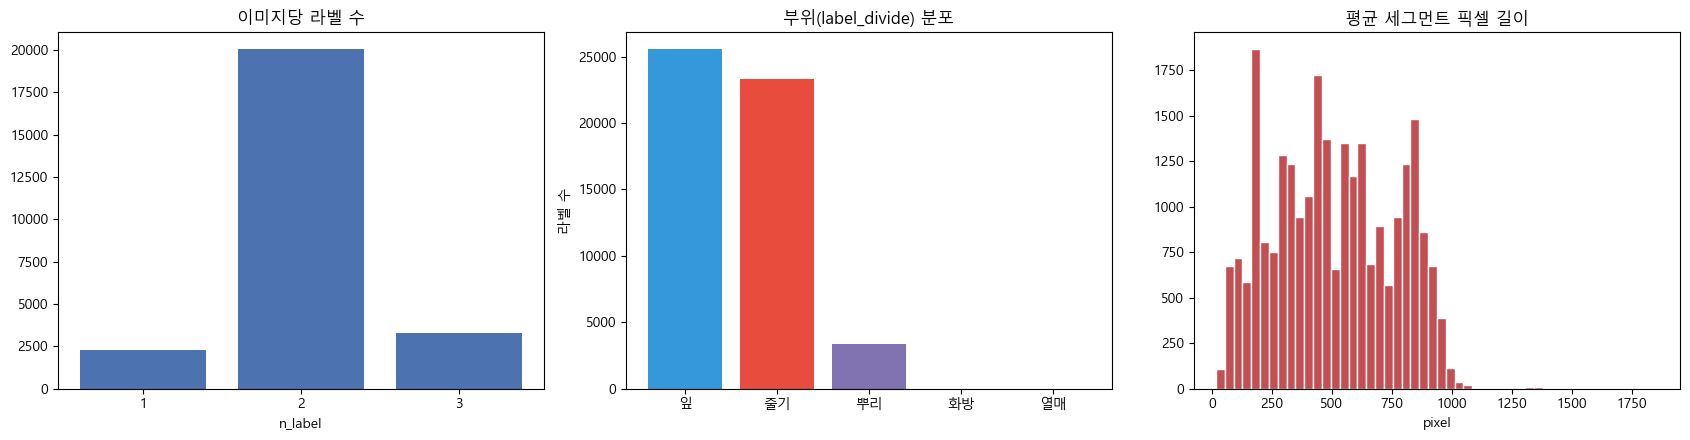

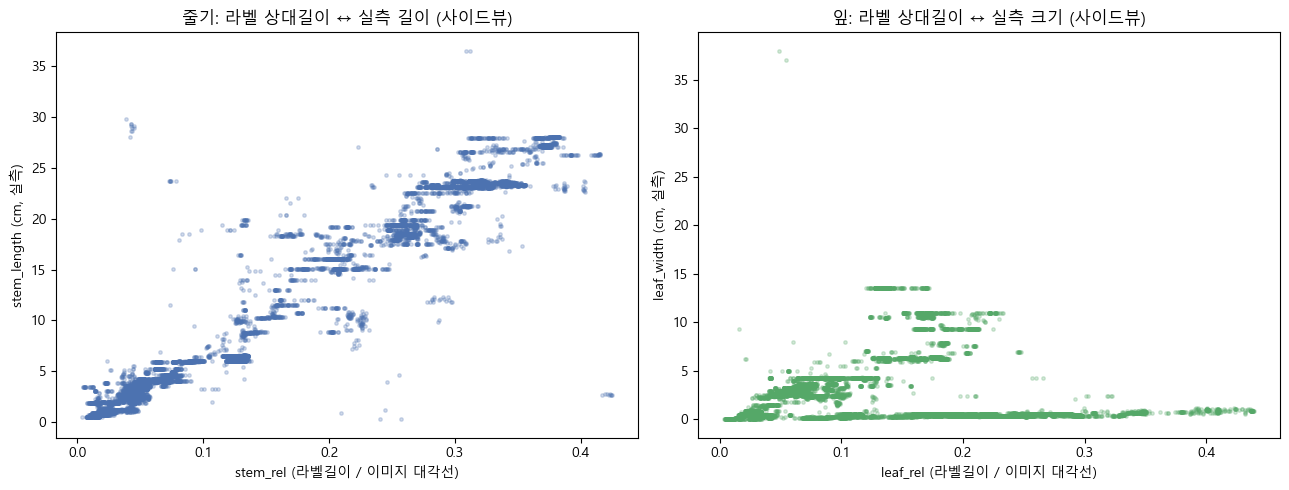

상관계수  줄기(rel vs cm): 0.976 / 잎(rel vs cm): -0.015


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

nl = df["n_label"].value_counts().sort_index()
axes[0].bar(nl.index.astype(int).astype(str), nl.values, color="#4C72B0")
axes[0].set_title("\uc774\ubbf8\uc9c0\ub2f9 \ub77c\ubca8 \uc218")
axes[0].set_xlabel("n_label")

dv = Counter()
for s in df["label_divide"]:
    for tok in [t.strip() for t in s.split(",") if t.strip()]:
        dv[tok] += 1
_palette = {"줄기": "#E74C3C", "잎": "#3498DB", "뿌리": "#8172B2"}
dv_items = dv.most_common()
axes[1].bar([k for k, _ in dv_items], [v for _, v in dv_items],
            color=[_palette.get(k, "#55A868") for k, _ in dv_items])
axes[1].set_title("\ubd80\uc704(label_divide) \ubd84\ud3ec")
axes[1].set_ylabel("\ub77c\ubca8 \uc218")

seg = df["seg_len_mean"].dropna()
axes[2].hist(seg, bins=50, color="#C44E52", edgecolor="white")
axes[2].set_title("\ud3c9\uade0 \uc138\uadf8\uba3c\ud2b8 \ud53d\uc140 \uae38\uc774")
axes[2].set_xlabel("pixel")

plt.tight_layout()
plt.savefig(EDA_OUT / "label_stats.png", dpi=120, bbox_inches="tight")
plt.show()

# 픽셀 길이 vs 실측치
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sv = df[df["view"] == "\uc0ac\uc774\ub4dc\ubdf0"].dropna(subset=["stem_rel", "stem_length"])
lv = df[df["view"] == "\uc0ac\uc774\ub4dc\ubdf0"].dropna(subset=["leaf_rel", "leaf_width"])
ax[0].scatter(sv["stem_rel"], sv["stem_length"], s=6, alpha=0.25, color="#4C72B0")
ax[0].set_xlabel("stem_rel (\ub77c\ubca8\uae38\uc774 / \uc774\ubbf8\uc9c0 \ub300\uac01\uc120)")
ax[0].set_ylabel("stem_length (cm, \uc2e4\uce21)")
ax[0].set_title("\uc904\uae30: \ub77c\ubca8 \uc0c1\ub300\uae38\uc774 \u2194 \uc2e4\uce21 \uae38\uc774 (\uc0ac\uc774\ub4dc\ubdf0)")
ax[1].scatter(lv["leaf_rel"], lv["leaf_width"], s=6, alpha=0.25, color="#55A868")
ax[1].set_xlabel("leaf_rel (\ub77c\ubca8\uae38\uc774 / \uc774\ubbf8\uc9c0 \ub300\uac01\uc120)")
ax[1].set_ylabel("leaf_width (cm, \uc2e4\uce21)")
ax[1].set_title("\uc78e: \ub77c\ubca8 \uc0c1\ub300\uae38\uc774 \u2194 \uc2e4\uce21 \ud06c\uae30 (\uc0ac\uc774\ub4dc\ubdf0)")
plt.tight_layout()
plt.savefig(EDA_OUT / "label_vs_measure.png", dpi=120, bbox_inches="tight")
plt.show()

corr_px = sv[["stem_rel", "stem_length"]].corr().iloc[0, 1]
corr_lf = lv[["leaf_rel", "leaf_width"]].corr().iloc[0, 1]
print(f"\uc0c1\uad00\uacc4\uc218  \uc904\uae30(rel vs cm): {corr_px:.3f} / \uc78e(rel vs cm): {corr_lf:.3f}")


## 7. 샘플 이미지 + 라벨(폴리라인) 시각화

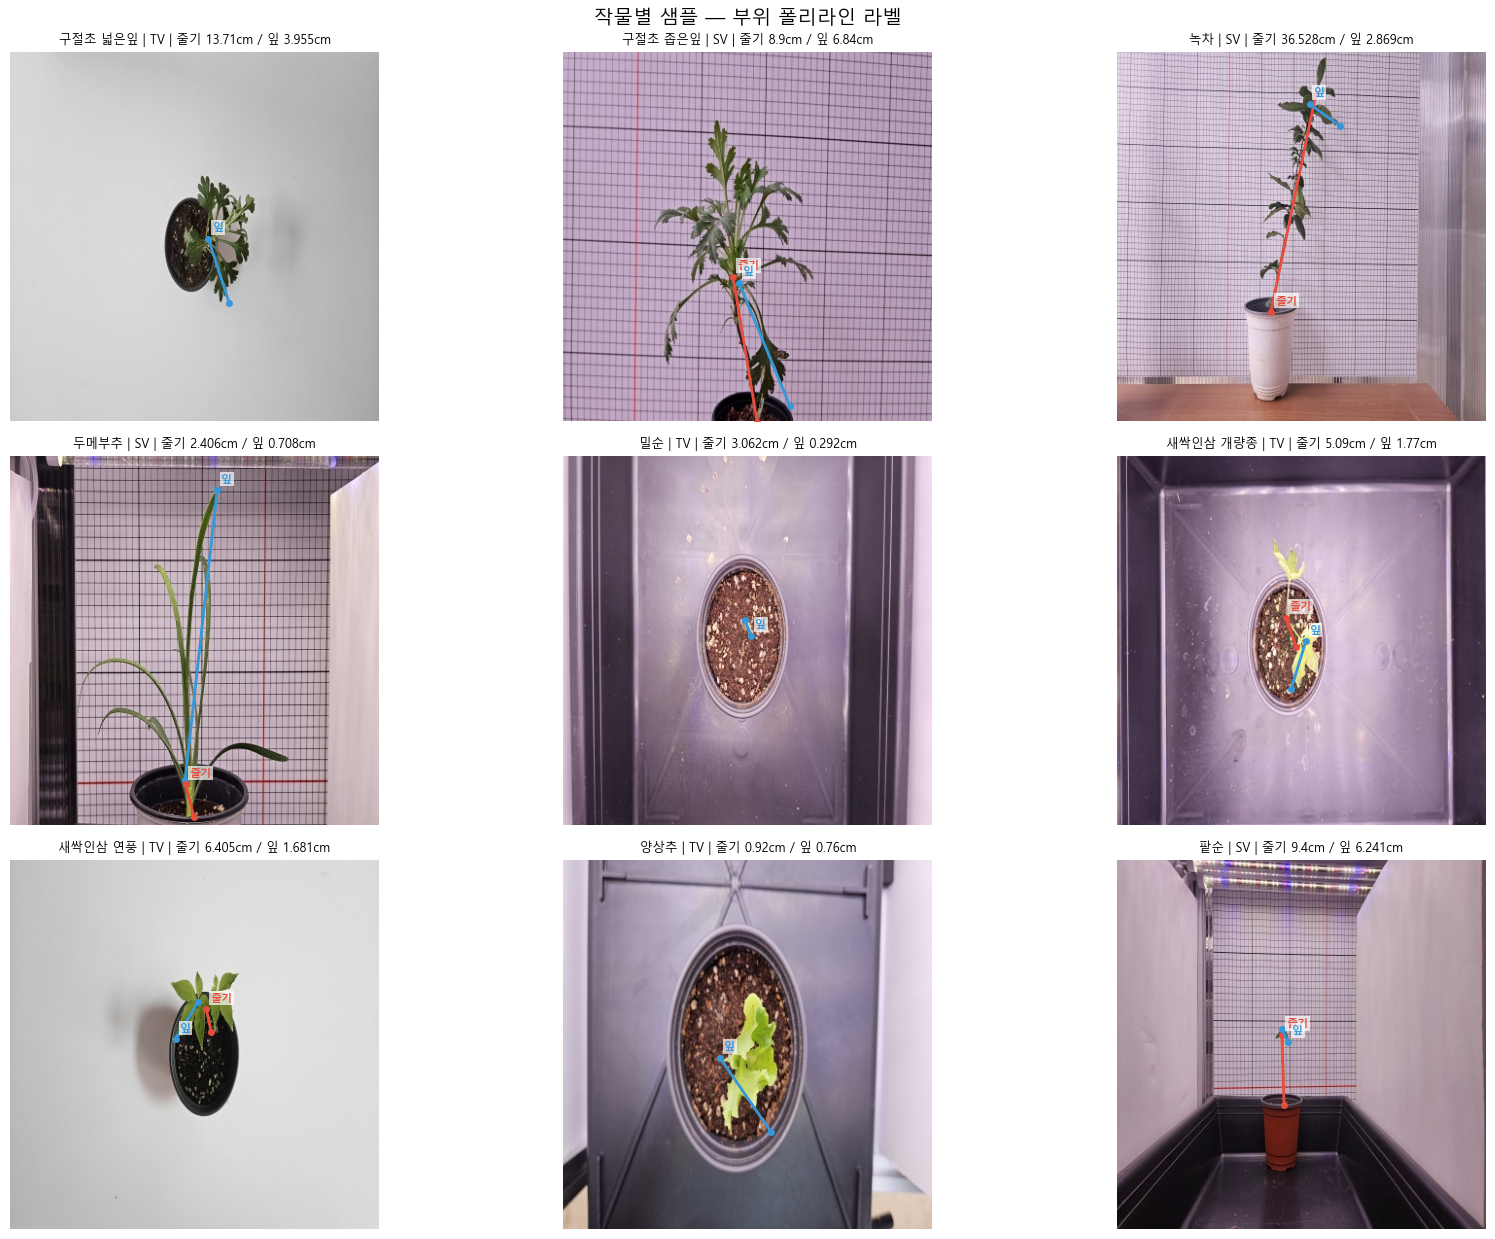

In [9]:
DIVIDE_COLORS = {"\uc904\uae30": "#E74C3C", "\uc78e": "#3498DB", "\ubfcc\ub9ac": "#8172B2"}


def draw_label(ax, json_path: Path, img_path: Path):
    """\ub77c\ubca8 \uc88c\ud45c\ub294 \uc6d0\ubcf8 \ud574\uc0c1\ub3c4 \uae30\uc900\uc774\ubbc0\ub85c \uc2e4\uc81c(\uc0d8\ud50c\uc740 380x380) \uc774\ubbf8\uc9c0 \ud06c\uae30\ub85c \uc2a4\ucf00\uc77c\ud574 \uadf8\ub9b0\ub2e4."""
    data = json.loads(Path(json_path).read_text(encoding="utf-8-sig"))
    im_meta = data.get("images", {}) or {}
    pil = Image.open(img_path)
    W, H = pil.size
    jw = im_meta.get("imagewidth") or W
    jh = im_meta.get("imageheight") or H
    sx, sy = W / jw, H / jh

    ax.imshow(pil)
    lab = data.get("labels", {}) or {}
    divides = _flatten_divide(lab.get("label_divide"))
    for div, seg in zip(divides, lab.get("label_points", [])):
        if not (isinstance(seg, list) and len(seg) >= 2):
            continue
        xs = [p[0] * sx for p in seg]
        ys = [p[1] * sy for p in seg]
        color = DIVIDE_COLORS.get(div, "#2ECC71")
        ax.plot(xs, ys, "-o", color=color, lw=2, ms=4)
        ax.annotate(div, (xs[0], ys[0]), textcoords="offset points", xytext=(3, 6),
                    color=color, fontsize=8, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))
    grw = data.get("growth", {})
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_title(f"{im_meta.get('class_name')} | {im_meta.get('photo_direction')} | "
                 f"\uc904\uae30 {grw.get('stem_length')}cm / \uc78e {grw.get('leaf_width')}cm",
                 fontsize=9)
    ax.axis("off")


# 작물별 대표 1장씩
picks = (df[df["img_exists"]]
         .sort_values("photo_dt")
         .groupby("crop", as_index=False)
         .first())

n = len(picks)
cols = 3
rows_ = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_, cols, figsize=(6 * cols, 4.2 * rows_))
for ax, (_, r) in zip(np.ravel(axes), picks.iterrows()):
    draw_label(ax, r["json_path"], r["img_path"])
for ax in np.ravel(axes)[n:]:
    ax.axis("off")
fig.suptitle("\uc791\ubb3c\ubcc4 \uc0d8\ud50c \u2014 \ubd80\uc704 \ud3f4\ub9ac\ub77c\uc778 \ub77c\ubca8", fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / "sample_labels.png", dpi=110, bbox_inches="tight")
plt.show()


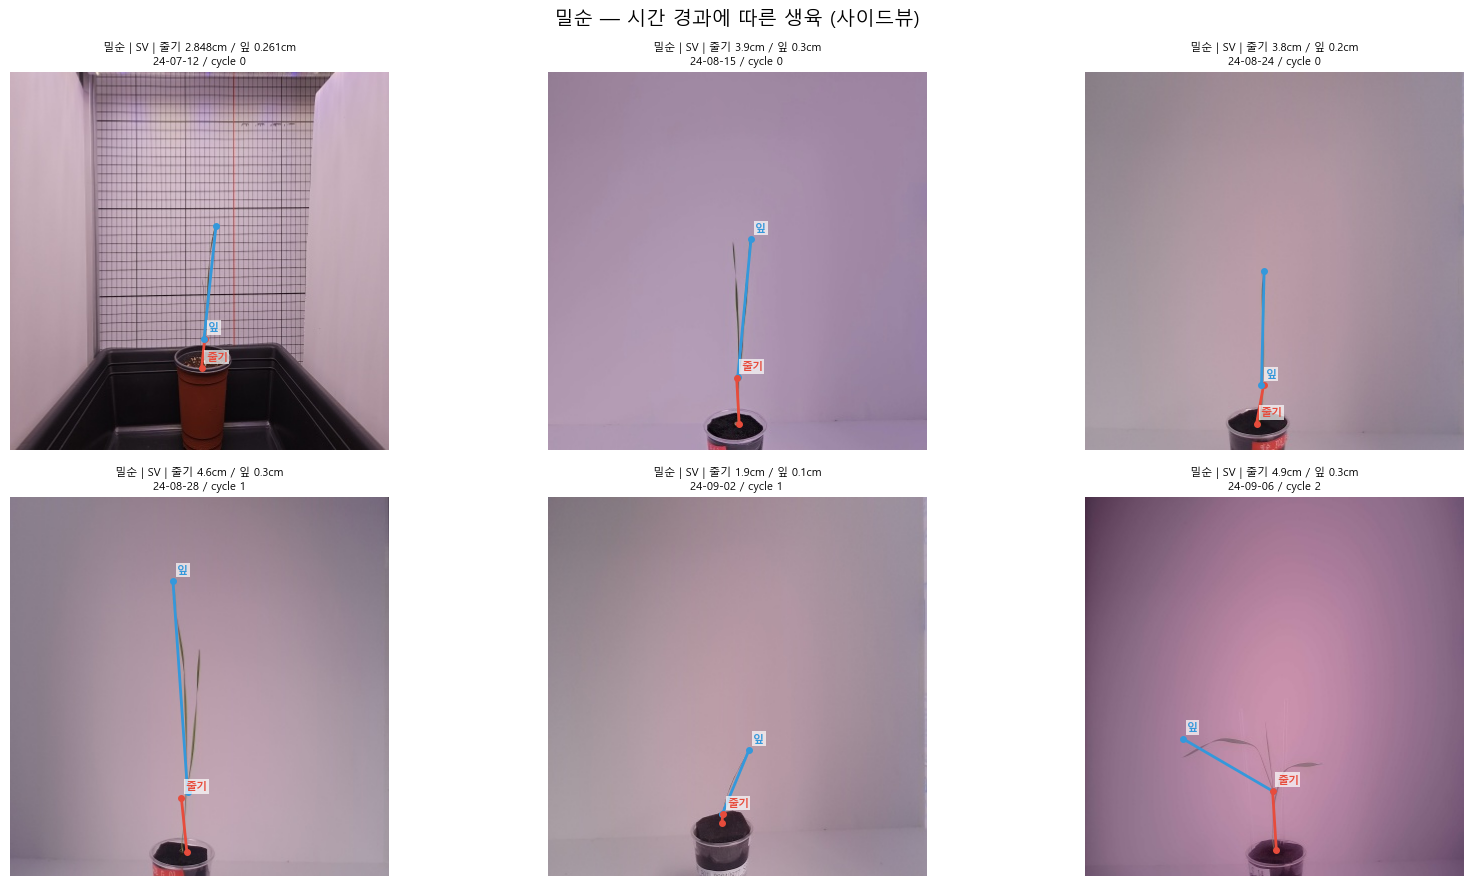

In [10]:
# 한 작물의 생장 → 수확 시계열 샘플 (밀순)
target = "\ubc00\uc21c"
seq = (df[(df["crop"] == target) & (df["img_exists"]) & (df["view"] == "\uc0ac\uc774\ub4dc\ubdf0")]
       .dropna(subset=["photo_dt"])
       .sort_values("photo_dt"))
if len(seq) >= 6:
    idx = np.linspace(0, len(seq) - 1, 6).astype(int)
    sub = seq.iloc[idx]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for ax, (_, r) in zip(axes.flat, sub.iterrows()):
        draw_label(ax, r["json_path"], r["img_path"])
        ax.set_title(ax.get_title() + f"\n{r['photo_dt']:%y-%m-%d} / cycle {r['growth_cycle']:.0f}", fontsize=8)
    fig.suptitle(f"{target} \u2014 \uc2dc\uac04 \uacbd\uacfc\uc5d0 \ub530\ub978 \uc0dd\uc721 (\uc0ac\uc774\ub4dc\ubdf0)", fontsize=14)
    plt.tight_layout()
    plt.savefig(EDA_OUT / "sample_timeline.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print(f"{target} \uc0ac\uc774\ub4dc\ubdf0 \uc0d8\ud50c \ubd80\uc871")


## 8. EDA 요약

| 항목 | 관찰 |
|------|------|
| 데이터 규모 | 이미지-라벨 1:1 페어 약 25,600쌍, 작물 9종 |
| 구분축 | `작물 × 생육단계(생장·수확) × 촬영방향(사이드뷰·탑뷰)` — 층화 분할 기준으로 활용 |
| 라벨 형식 | 부위별(`줄기`·`잎`·`뿌리`) **2점 폴리라인** → B-box가 아닌 **키포인트/길이 회귀** 과제에 적합 |
| 부가 라벨 | 환경 센서(온·습도·CO2·조도·EC·pH) + 생육 실측치(줄기길이·두께·잎크기·잎수) + 캡션 |
| 결측 처리 | 수확기 레코드의 일부 환경 필드가 `"-"` → 수치 변환 시 NaN, 분석 전 마스킹 필요 |
| 해상도 주의 | 샘플 JPG는 **380×380 축소본**이지만 `label_points`는 원본(1920/3840) 좌표 → 시각화·학습 시 스케일 변환 필수 |
| 활용 방향 | ① 부위 키포인트 검출 ② 이미지→생육수치 회귀 ③ 환경-생육 상관 모델링 ④ 캡션 기반 멀티모달 |

<br>

> 산출물은 `green_bio_farm/eda/` 에 PNG로 저장됩니다.
